In [1]:
import os
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
print("Folders created!")

Folders created!


In [2]:
import os
print(os.listdir("data"))

['processed', 'raw']


In [1]:
import shutil, os

# Move the downloaded file from Downloads into data/raw
src = os.path.expanduser("~/Downloads/d07_text_station_5min_2022_09_01.txt.gz")
dst = "data/raw/d07_text_station_5min_2022_09_01.txt.gz"

shutil.move(src, dst)
print("Moved. data/raw now contains:", os.listdir("data/raw"))

Moved. data/raw now contains: ['d07_text_station_5min_2022_09_01.txt.gz']


In [2]:
import pandas as pd

# Read the gzipped file. header=None because PeMS files have no column names.
df = pd.read_csv("data/raw/d07_text_station_5min_2022_09_01.txt.gz", header=None)

print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (1409755, 52)


,0,1,2,3,4,5,6,7,8,9,...,42,43,44,45,46,47,48,49,50,51
0,09/01/2022 00:00:00,715898,7,5,S,ML,0.43,0,0,225.0,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
1,09/01/2022 00:00:00,715900,7,5,S,OR,NaN,0,0,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
2,09/01/2022 00:00:00,715901,7,5,N,OR,NaN,0,0,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
3,09/01/2022 00:00:00,715903,7,5,N,OR,NaN,0,0,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
4,09/01/2022 00:00:00,715904,7,5,S,OR,NaN,0,0,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0


In [3]:
# Show all 52 columns for the first few MAINLINE rows of YOUR freeway (SR-60)
# Column 1 = station, col 3 = freeway, col 5 = lane type
sr60 = df[(df[3] == 60) & (df[5] == "ML")]
print("SR-60 mainline rows found:", len(sr60))
pd.set_option("display.max_columns", None)   # show every column
sr60.head()

SR-60 mainline rows found: 40320


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51
247,09/01/2022 00:00:00,716206,7,60,W,ML,0.540,0,0,18.0,0.0092,65.3,0.0,5.0,0.0065,68.6,0,0.0,8.0,0.0116,66.5,0,0.0,5.0,0.0095,59.8,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
253,09/01/2022 00:00:00,716213,7,60,E,ML,0.470,0,0,224.0,0.0395,70.0,0.0,47.0,0.0280,75.9,0,0.0,68.0,0.0435,72.0,0,0.0,60.0,0.0453,68.4,0,0.0,49.0,0.0412,63.7,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
275,09/01/2022 00:00:00,716235,7,60,E,ML,0.560,0,0,145.0,0.0307,69.2,0.0,30.0,0.0218,75.0,0,0.0,44.0,0.0338,71.2,0,0.0,39.0,0.0352,67.6,0,0.0,32.0,0.0320,63.0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
276,09/01/2022 00:00:00,716237,7,60,E,ML,0.535,40,0,217.0,0.0356,69.3,10.0,4.0,0.0028,76.5,0,10.0,37.0,0.0280,74.0,0,10.0,52.0,0.0443,71.5,0,10.0,60.0,0.0725,69.2,0,0.0,36.0,0.0388,64.4,0,0.0,28.0,0.0271,64.4,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
277,09/01/2022 00:00:00,716238,7,60,W,ML,0.569,0,0,145.0,0.0307,69.9,0.0,32.0,0.0245,74.3,0,0.0,35.0,0.0333,71.9,0,0.0,31.0,0.0363,69.9,0,0.0,29.0,0.0346,67.2,0,0.0,18.0,0.0248,62.7,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0


In [4]:
# Your 6 study stations (SR-60 westbound)
my_stations = [766788, 774926, 774958, 776657, 774946, 776690]

# Keep only your stations, mainline, westbound
sub = df[(df[1].isin(my_stations)) & (df[5] == "ML") & (df[4] == "W")].copy()

# Give the columns we care about real names
sub = sub.rename(columns={0:"timestamp", 1:"station", 4:"dir",
                          6:"length", 8:"pct_obs", 9:"flow", 11:"speed"})

# How many rows per station did we get?
print("Rows per station:")
print(sub["station"].value_counts())

# Peek at the key columns
sub[["timestamp","station","length","pct_obs","flow","speed"]].head()

Rows per station:
station
766788    288
774926    288
774946    288
774958    288
776657    288
776690    288
Name: count, dtype: int64


,timestamp,station,length,pct_obs,flow,speed
3262,09/01/2022 00:00:00,766788,1.433,0,113.0,68.3
4583,09/01/2022 00:00:00,774926,0.555,0,202.0,70.5
4588,09/01/2022 00:00:00,774946,0.325,0,152.0,70.3
4592,09/01/2022 00:00:00,774958,0.325,0,225.0,70.4
4828,09/01/2022 00:00:00,776657,0.200,0,360.0,69.6


In [5]:
# Check pct_obs and speed during PM peak (3-7pm) at the merge station
pm = sub[(sub["station"]==774926) &
         (sub["timestamp"].str.contains("15:|16:|17:|18:"))]
print(pm[["timestamp","pct_obs","flow","speed"]].head(20))

                  timestamp  pct_obs   flow  speed
19265   09/01/2022 00:15:00        0  177.0   69.7
78004   09/01/2022 01:15:00        0  126.0   70.0
136744  09/01/2022 02:15:00        0  156.0   66.3
195484  09/01/2022 03:15:00        0  258.0   67.7
254224  09/01/2022 04:15:00        0  505.0   71.4
312964  09/01/2022 05:15:00        0  863.0   79.4
371704  09/01/2022 06:15:00        0  822.0   32.4
430444  09/01/2022 07:15:00        0  773.0   27.8
489184  09/01/2022 08:15:00        0  753.0   31.5
547924  09/01/2022 09:15:00        0  677.0   25.7
606664  09/01/2022 10:15:00        0  684.0   26.0
665404  09/01/2022 11:15:00        0  667.0   24.7
724144  09/01/2022 12:15:00        0  750.0   28.1
782884  09/01/2022 13:15:00        0  803.0   42.1
841624  09/01/2022 14:15:00        0  818.0   49.8
885679  09/01/2022 15:00:00        0  818.0   39.5
890574  09/01/2022 15:05:00        0  793.0   42.6
895469  09/01/2022 15:10:00        0  813.0   44.2
900364  09/01/2022 15:15:00    

In [6]:
# Look at a busy afternoon row across ALL columns to find % observed
# Re-filter from the raw df so we see original column numbers
busy = df[(df[1]==774926) & (df[5]=="ML") & (df[4]=="W")]
busy = busy[busy[0].str.contains("17:00:00")]   # 5pm, should be busy
print(busy.iloc[0].to_string())

0     09/01/2022 17:00:00
1                  774926
2                       7
3                      60
4                       W
5                      ML
6                   0.555
7                      60
8                       0
9                   766.0
10                 0.2933
11                   34.1
12                   10.0
13                  139.0
14                 0.2853
15                   40.1
16                      0
17                   10.0
18                  133.0
19                 0.2863
20                   38.4
21                      0
22                   10.0
23                  114.0
24                 0.2839
25                   37.3
26                      0
27                   10.0
28                  115.0
29                 0.2695
30                   34.6
31                      0
32                   10.0
33                  143.0
34                 0.2949
35                   30.2
36                      0
37                   10.0
38          

In [7]:
# Compare columns 7 and 8 over the full day for the merge station
chk = df[(df[1]==774926) & (df[5]=="ML") & (df[4]=="W")]
print("Column 7 stats:", chk[7].min(), chk[7].max(), chk[7].mean().round(1))
print("Column 8 stats:", chk[8].min(), chk[8].max(), chk[8].mean().round(1))
print("Column 11 (speed) NaN count:", chk[11].isna().sum())

Column 7 stats: 48 60 60.0
Column 8 stats: 0 0 0.0
Column 11 (speed) NaN count: 0


In [8]:
import pandas as pd
import os

# Build the list of every expected file (Sept 1 - Dec 9, 2022)
expected_dates = pd.date_range("2022-09-01", "2022-12-09", freq="D")

def expected_filename(d):
    return f"d07_text_station_5min_2022_{d.month:02d}_{d.day:02d}.txt.gz"

expected_files = [expected_filename(d) for d in expected_dates]

# See what's actually in data/raw
have = set(os.listdir("data/raw"))
have = {f for f in have if f.endswith(".txt.gz")}

# Compare
missing = [f for f in expected_files if f not in have]
present = [f for f in expected_files if f in have]

print(f"Downloaded: {len(present)} / {len(expected_files)}")
print(f"Still missing: {len(missing)}")
print()
# Show missing grouped by month so you know what to grab next
for month, name in [(9,"September"), (10,"October"), (11,"November"), (12,"December")]:
    miss_m = [f for f in missing if f"_2022_{month:02d}_" in f]
    if miss_m:
        days = sorted(int(f.split("_")[-1].replace(".txt.gz","")) for f in miss_m)
        print(f"{name}: missing {len(miss_m)} days -> {days}")

Downloaded: 1 / 100
Still missing: 99

September: missing 29 days -> [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
October: missing 31 days -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
November: missing 30 days -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
December: missing 9 days -> [1, 2, 3, 4, 5, 6, 7, 8, 9]


In [9]:
import shutil, os, glob
moved = 0
for src in glob.glob(os.path.expanduser("~/Downloads/d07_text_station_5min_2022_*.txt.gz")):
    dst = os.path.join("data/raw", os.path.basename(src))
    if not os.path.exists(dst):
        shutil.move(src, dst)
        moved += 1
print(f"Moved {moved} files into data/raw")

Moved 18 files into data/raw


In [10]:
import shutil, os, glob
moved = 0
for src in glob.glob(os.path.expanduser("~/Downloads/d07_text_station_5min_2022_*.txt.gz")):
    dst = os.path.join("data/raw", os.path.basename(src))
    if not os.path.exists(dst):
        shutil.move(src, dst)
        moved += 1
print(f"Moved {moved} files into data/raw")

Moved 11 files into data/raw


In [11]:
import pandas as pd
import os

# Build the list of every expected file (Sept 1 - Dec 9, 2022)
expected_dates = pd.date_range("2022-09-01", "2022-12-09", freq="D")

def expected_filename(d):
    return f"d07_text_station_5min_2022_{d.month:02d}_{d.day:02d}.txt.gz"

expected_files = [expected_filename(d) for d in expected_dates]

# See what's actually in data/raw
have = set(os.listdir("data/raw"))
have = {f for f in have if f.endswith(".txt.gz")}

# Compare
missing = [f for f in expected_files if f not in have]
present = [f for f in expected_files if f in have]

print(f"Downloaded: {len(present)} / {len(expected_files)}")
print(f"Still missing: {len(missing)}")
print()
# Show missing grouped by month so you know what to grab next
for month, name in [(9,"September"), (10,"October"), (11,"November"), (12,"December")]:
    miss_m = [f for f in missing if f"_2022_{month:02d}_" in f]
    if miss_m:
        days = sorted(int(f.split("_")[-1].replace(".txt.gz","")) for f in miss_m)
        print(f"{name}: missing {len(miss_m)} days -> {days}")

Downloaded: 30 / 100
Still missing: 70

October: missing 31 days -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
November: missing 30 days -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
December: missing 9 days -> [1, 2, 3, 4, 5, 6, 7, 8, 9]


In [12]:
import shutil, os, glob
moved = 0
for src in glob.glob(os.path.expanduser("~/Downloads/d07_text_station_5min_2022_*.txt.gz")):
    dst = os.path.join("data/raw", os.path.basename(src))
    if not os.path.exists(dst):
        shutil.move(src, dst)
        moved += 1
print(f"Moved {moved} files into data/raw")

Moved 31 files into data/raw


In [13]:
import pandas as pd
import os

# Build the list of every expected file (Sept 1 - Dec 9, 2022)
expected_dates = pd.date_range("2022-09-01", "2022-12-09", freq="D")

def expected_filename(d):
    return f"d07_text_station_5min_2022_{d.month:02d}_{d.day:02d}.txt.gz"

expected_files = [expected_filename(d) for d in expected_dates]

# See what's actually in data/raw
have = set(os.listdir("data/raw"))
have = {f for f in have if f.endswith(".txt.gz")}

# Compare
missing = [f for f in expected_files if f not in have]
present = [f for f in expected_files if f in have]

print(f"Downloaded: {len(present)} / {len(expected_files)}")
print(f"Still missing: {len(missing)}")
print()
# Show missing grouped by month so you know what to grab next
for month, name in [(9,"September"), (10,"October"), (11,"November"), (12,"December")]:
    miss_m = [f for f in missing if f"_2022_{month:02d}_" in f]
    if miss_m:
        days = sorted(int(f.split("_")[-1].replace(".txt.gz","")) for f in miss_m)
        print(f"{name}: missing {len(miss_m)} days -> {days}")

Downloaded: 61 / 100
Still missing: 39

November: missing 30 days -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
December: missing 9 days -> [1, 2, 3, 4, 5, 6, 7, 8, 9]


In [14]:
import shutil, os, glob
moved = 0
for src in glob.glob(os.path.expanduser("~/Downloads/d07_text_station_5min_2022_*.txt.gz")):
    dst = os.path.join("data/raw", os.path.basename(src))
    if not os.path.exists(dst):
        shutil.move(src, dst)
        moved += 1
print(f"Moved {moved} files into data/raw")

Moved 30 files into data/raw


In [15]:
import pandas as pd
import os

# Build the list of every expected file (Sept 1 - Dec 9, 2022)
expected_dates = pd.date_range("2022-09-01", "2022-12-09", freq="D")

def expected_filename(d):
    return f"d07_text_station_5min_2022_{d.month:02d}_{d.day:02d}.txt.gz"

expected_files = [expected_filename(d) for d in expected_dates]

# See what's actually in data/raw
have = set(os.listdir("data/raw"))
have = {f for f in have if f.endswith(".txt.gz")}

# Compare
missing = [f for f in expected_files if f not in have]
present = [f for f in expected_files if f in have]

print(f"Downloaded: {len(present)} / {len(expected_files)}")
print(f"Still missing: {len(missing)}")
print()
# Show missing grouped by month so you know what to grab next
for month, name in [(9,"September"), (10,"October"), (11,"November"), (12,"December")]:
    miss_m = [f for f in missing if f"_2022_{month:02d}_" in f]
    if miss_m:
        days = sorted(int(f.split("_")[-1].replace(".txt.gz","")) for f in miss_m)
        print(f"{name}: missing {len(miss_m)} days -> {days}")

Downloaded: 91 / 100
Still missing: 9

December: missing 9 days -> [1, 2, 3, 4, 5, 6, 7, 8, 9]


In [16]:
import shutil, os, glob
moved = 0
for src in glob.glob(os.path.expanduser("~/Downloads/d07_text_station_5min_2022_*.txt.gz")):
    dst = os.path.join("data/raw", os.path.basename(src))
    if not os.path.exists(dst):
        shutil.move(src, dst)
        moved += 1
print(f"Moved {moved} files into data/raw")

Moved 9 files into data/raw


In [17]:
import pandas as pd
import os

# Build the list of every expected file (Sept 1 - Dec 9, 2022)
expected_dates = pd.date_range("2022-09-01", "2022-12-09", freq="D")

def expected_filename(d):
    return f"d07_text_station_5min_2022_{d.month:02d}_{d.day:02d}.txt.gz"

expected_files = [expected_filename(d) for d in expected_dates]

# See what's actually in data/raw
have = set(os.listdir("data/raw"))
have = {f for f in have if f.endswith(".txt.gz")}

# Compare
missing = [f for f in expected_files if f not in have]
present = [f for f in expected_files if f in have]

print(f"Downloaded: {len(present)} / {len(expected_files)}")
print(f"Still missing: {len(missing)}")
print()
# Show missing grouped by month so you know what to grab next
for month, name in [(9,"September"), (10,"October"), (11,"November"), (12,"December")]:
    miss_m = [f for f in missing if f"_2022_{month:02d}_" in f]
    if miss_m:
        days = sorted(int(f.split("_")[-1].replace(".txt.gz","")) for f in miss_m)
        print(f"{name}: missing {len(miss_m)} days -> {days}")

Downloaded: 100 / 100
Still missing: 0



In [18]:
import pandas as pd
import glob
import os

# Your 6 study stations (SR-60 westbound)
my_stations = [766788, 774926, 774958, 776657, 774946, 776690]

# Column names for the fields we keep (verified column map)
col_names = {0:"timestamp", 1:"station", 3:"freeway", 4:"dir",
             5:"lanetype", 6:"length", 7:"samples", 9:"flow", 11:"speed"}

# Find all raw files, sorted so they process in date order
raw_files = sorted(glob.glob("data/raw/d07_text_station_5min_2022_*.txt.gz"))
print(f"Found {len(raw_files)} raw files to process.\n")

pieces = []
for i, path in enumerate(raw_files, 1):
    # Read only the columns we need (faster, less memory)
    df = pd.read_csv(path, header=None, usecols=list(col_names.keys()))
    df = df.rename(columns=col_names)
    # Filter to your stations, mainline, westbound
    keep = df[(df["station"].isin(my_stations)) &
              (df["lanetype"] == "ML") &
              (df["dir"] == "W")].copy()
    pieces.append(keep)
    if i % 10 == 0 or i == len(raw_files):
        print(f"  processed {i}/{len(raw_files)} files...")

# Stack all the daily pieces into one table
data = pd.concat(pieces, ignore_index=True)

# Turn timestamp text into real datetime values
data["timestamp"] = pd.to_datetime(data["timestamp"], format="%m/%d/%Y %H:%M:%S")

print(f"\nDone. Combined table: {data.shape[0]:,} rows x {data.shape[1]} columns")
print(f"Date range: {data['timestamp'].min()}  to  {data['timestamp'].max()}")
print(f"Rows per station:")
print(data["station"].value_counts().sort_index())

Found 100 raw files to process.

  processed 10/100 files...
  processed 20/100 files...
  processed 30/100 files...
  processed 40/100 files...
  processed 50/100 files...
  processed 60/100 files...
  processed 70/100 files...
  processed 80/100 files...
  processed 90/100 files...
  processed 100/100 files...

Done. Combined table: 172,800 rows x 9 columns
Date range: 2022-09-01 00:00:00  to  2022-12-09 23:55:00
Rows per station:
station
766788    28800
774926    28800
774946    28800
774958    28800
776657    28800
776690    28800
Name: count, dtype: int64


In [19]:
# Save the combined clean dataset so we never re-run the slow loop
out_path = "data/processed/sr60wb_5min_sep_dec_2022.parquet"
data.to_parquet(out_path)
print("Saved to", out_path)
print("File size:", round(os.path.getsize(out_path)/1e6, 1), "MB")

# Quick reload test to confirm it works
test = pd.read_parquet(out_path)
print("Reloaded OK:", test.shape)

Saved to data/processed/sr60wb_5min_sep_dec_2022.parquet
File size: 1.0 MB
Reloaded OK: (172800, 9)


In [20]:
import pandas as pd

# Reload the clean dataset (so this works in a fresh session too)
data = pd.read_parquet("data/processed/sr60wb_5min_sep_dec_2022.parquet")

# --- Add helper time columns ---
data["date"]    = data["timestamp"].dt.date
data["dow"]     = data["timestamp"].dt.dayofweek          # Mon=0 ... Sun=6
data["time_of_day"] = data["timestamp"].dt.strftime("%H:%M")  # "00:00" ... "23:55"

# --- Define what to exclude from the recurrent baseline ---
# Weekends:
is_weekend = data["dow"] >= 5
# Holidays in the window (atypical traffic): Labor Day, Veterans Day, Thanksgiving + day after
holidays = pd.to_datetime(["2022-09-05","2022-11-11","2022-11-24","2022-11-25"]).date
is_holiday = data["date"].isin(holidays)

# Weekday baseline pool = weekdays, excluding holidays
baseline_pool = data[~is_weekend & ~is_holiday].copy()

print("Total rows:", len(data))
print("Baseline pool rows (weekdays, no holidays):", len(baseline_pool))
print("Weekdays used:", baseline_pool["date"].nunique())
print("Time-of-day slots:", baseline_pool["time_of_day"].nunique())

Total rows: 172800
Baseline pool rows (weekdays, no holidays): 117504
Weekdays used: 68
Time-of-day slots: 288


In [21]:
# --- Build the recurrent baseline: median speed per station per time-of-day ---
baseline = (baseline_pool
            .groupby(["station", "time_of_day"])["speed"]
            .median()
            .reset_index()
            .rename(columns={"speed": "baseline_speed"}))

print("Baseline shape:", baseline.shape, "(should be 6 stations x 288 slots = 1728)")
print()

# Peek at the merge station's baseline around the PM peak
merge_pm = baseline[(baseline["station"]==774926) &
                    (baseline["time_of_day"].between("15:00","18:00"))]
print("Merge station (774926) typical speed, 3-6 PM:")
print(merge_pm.to_string(index=False))

Baseline shape: (1728, 3) (should be 6 stations x 288 slots = 1728)

Merge station (774926) typical speed, 3-6 PM:
 station time_of_day  baseline_speed
  774926       15:00           46.55
  774926       15:05           45.70
  774926       15:10           44.75
  774926       15:15           44.20
  774926       15:20           42.00
  774926       15:25           40.60
  774926       15:30           40.05
  774926       15:35           40.75
  774926       15:40           43.20
  774926       15:45           42.95
  774926       15:50           41.95
  774926       15:55           41.80
  774926       16:00           41.75
  774926       16:05           43.55
  774926       16:10           46.35
  774926       16:15           46.05
  774926       16:20           46.00
  774926       16:25           44.50
  774926       16:30           43.95
  774926       16:35           45.05
  774926       16:40           45.95
  774926       16:45           46.85
  774926       16:50           46.

Matplotlib is building the font cache; this may take a moment.


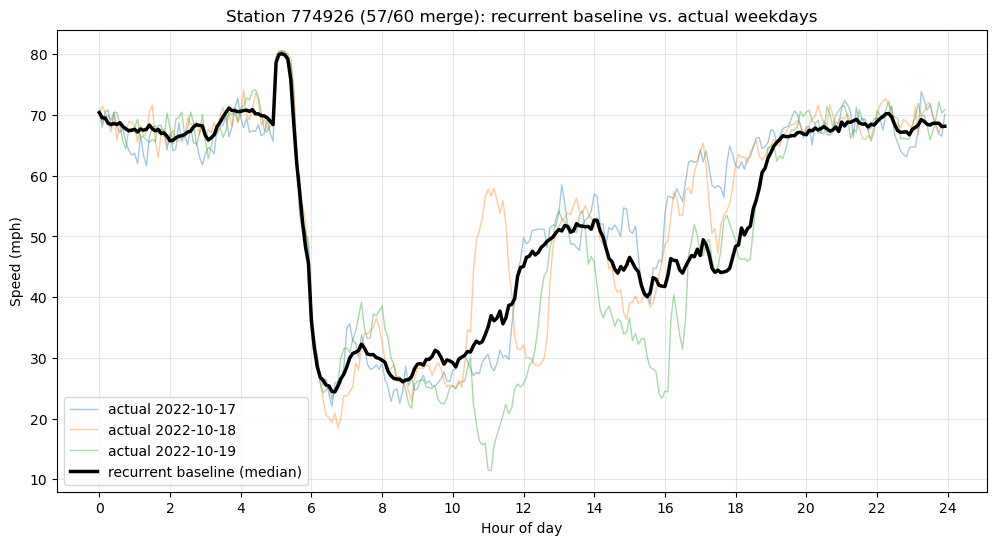

In [22]:
import matplotlib.pyplot as plt

# Pick the merge station to visualize
st = 774926

# Baseline curve (typical day), ordered by time
b = baseline[baseline["station"]==st].sort_values("time_of_day")

# Convert "HH:MM" to a fractional hour for plotting on x-axis
def to_hour(s):
    h, m = s.split(":")
    return int(h) + int(m)/60
b_x = b["time_of_day"].map(to_hour)

# Grab a few sample weekdays of REAL data to overlay
sample_days = ["2022-10-17","2022-10-18","2022-10-19"]  # a normal week, Mon-Wed
plt.figure(figsize=(12,6))

for d in sample_days:
    day = baseline_pool[(baseline_pool["station"]==st) &
                        (baseline_pool["date"]==pd.to_datetime(d).date())].sort_values("time_of_day")
    day_x = day["time_of_day"].map(to_hour)
    plt.plot(day_x, day["speed"], alpha=0.4, linewidth=1, label=f"actual {d}")

# Plot the baseline on top, bold
plt.plot(b_x, b["baseline_speed"], color="black", linewidth=2.5, label="recurrent baseline (median)")

plt.xlabel("Hour of day")
plt.ylabel("Speed (mph)")
plt.title(f"Station {st} (57/60 merge): recurrent baseline vs. actual weekdays")
plt.xticks(range(0,25,2))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

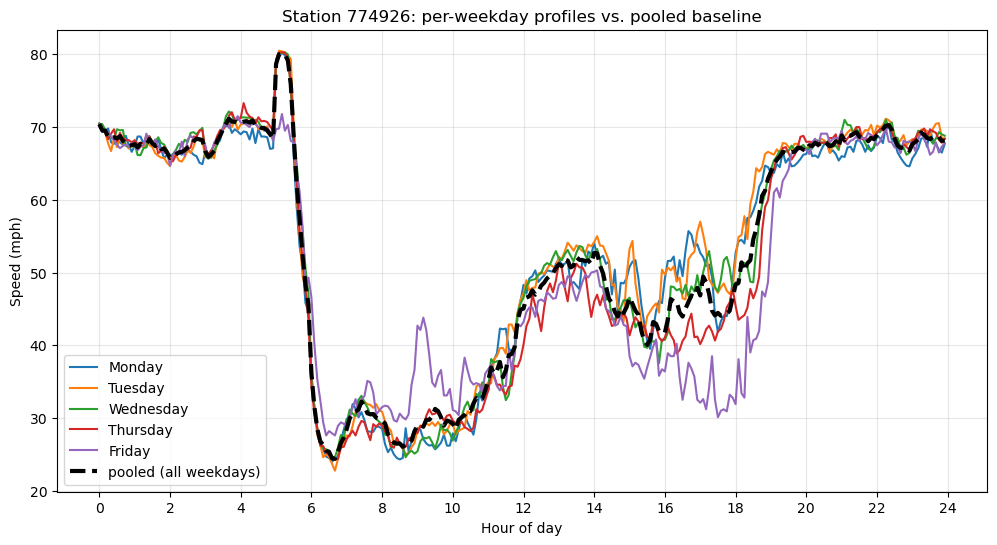

In [23]:
import matplotlib.pyplot as plt

st = 774926  # merge station

# Build a separate median profile for each weekday (Mon..Fri)
dow_names = {0:"Monday",1:"Tuesday",2:"Wednesday",3:"Thursday",4:"Friday"}

plt.figure(figsize=(12,6))
for d, name in dow_names.items():
    sub = baseline_pool[(baseline_pool["station"]==st) & (baseline_pool["dow"]==d)]
    prof = sub.groupby("time_of_day")["speed"].median().reset_index()
    prof = prof.sort_values("time_of_day")
    x = prof["time_of_day"].map(lambda s: int(s[:2]) + int(s[3:])/60)
    plt.plot(x, prof["speed"], linewidth=1.5, label=name)

# Overlay the pooled baseline in bold black for comparison
b = baseline[baseline["station"]==st].sort_values("time_of_day")
bx = b["time_of_day"].map(lambda s: int(s[:2]) + int(s[3:])/60)
plt.plot(bx, b["baseline_speed"], color="black", linewidth=3, linestyle="--", label="pooled (all weekdays)")

plt.xlabel("Hour of day"); plt.ylabel("Speed (mph)")
plt.title(f"Station {st}: per-weekday profiles vs. pooled baseline")
plt.xticks(range(0,25,2)); plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [24]:
# --- Empirical free-flow reference speed per station ---
# Use genuinely uncongested periods: overnight hours (0-4 AM) across ALL days
# (weekday + weekend), when the bottleneck is provably inactive.

overnight = data[data["timestamp"].dt.hour < 4]   # 00:00-03:55

# Free-flow = a high percentile of overnight speed (the uncongested "fast" condition).
# 85th percentile is a common, robust choice (avoids being skewed by rare slow blips).
freeflow = (overnight.groupby("station")["speed"]
            .quantile(0.85)
            .round(1)
            .rename("freeflow_speed"))

print("Empirical free-flow speed per station (85th pct of overnight speed):")
print(freeflow)
print()
print("For comparison — overnight median and max per station:")
print(overnight.groupby("station")["speed"].agg(["median","max"]).round(1))

Empirical free-flow speed per station (85th pct of overnight speed):
station
766788    68.2
774926    70.9
774946    70.5
774958    68.9
776657    66.3
776690    69.5
Name: freeflow_speed, dtype: float64

For comparison — overnight median and max per station:
         median   max
station              
766788     65.3  73.2
774926     68.2  79.1
774946     68.6  78.3
774958     66.6  75.3
776657     65.0  73.3
776690     66.9  76.0


In [25]:
import numpy as np

# Attach each station's free-flow speed to every row
data = data.merge(freeflow, on="station", how="left")

# Vehicles per 5-min interval: flow is veh/HOUR, interval is 5 min = 1/12 hour
data["n_veh"] = data["flow"] * (5/60)

# Delay per interval (vehicle-hours):
#   extra hours per vehicle = L * (1/v_obs - 1/v_freeflow), only when slower than free-flow
inv_obs = 1.0 / data["speed"]
inv_ff  = 1.0 / data["freeflow_speed"]
extra_hours_per_veh = data["length"] * (inv_obs - inv_ff)

# Floor at 0: no "negative delay" when faster than free-flow
extra_hours_per_veh = extra_hours_per_veh.clip(lower=0)

# Total vehicle-hours of delay in this interval
data["vhd"] = data["n_veh"] * extra_hours_per_veh

# --- Sanity check: total delay over the whole period & window ---
print("Total VHD (all stations, all 100 days, all hours): {:,.0f} veh-hours".format(data["vhd"].sum()))
print()
print("Total VHD per station:")
print(data.groupby("station")["vhd"].sum().round(0))

Total VHD (all stations, all 100 days, all hours): 15,585 veh-hours

Total VHD per station:
station
766788    6301.0
774926    5830.0
774946    1349.0
774958    1263.0
776657     546.0
776690     296.0
Name: vhd, dtype: float64


In [26]:
# When does the delay occur? Sum VHD by hour of day (should peak during congested hours)
data["hour"] = data["timestamp"].dt.hour
by_hour = data.groupby("hour")["vhd"].sum().round(0)
print("Total VHD by hour of day:")
print(by_hour)

Total VHD by hour of day:
hour
0       48.0
1       51.0
2       51.0
3       51.0
4       58.0
5      193.0
6     1682.0
7     1599.0
8     1708.0
9     1443.0
10    1307.0
11    1187.0
12     843.0
13     801.0
14     828.0
15     880.0
16     818.0
17     849.0
18     618.0
19     229.0
20     126.0
21      80.0
22      74.0
23      64.0
Name: vhd, dtype: float64


In [27]:
# --- Define the congested window empirically from the baseline ---
# Compute recurrent delay per time-of-day slot (corridor total), find where it's non-negligible.

# Recurrent delay per row = delay computed against BASELINE speed (the "typical day" delay)
data = data.merge(baseline, on=["station","time_of_day"], how="left")

inv_base = 1.0 / data["baseline_speed"]
inv_ff   = 1.0 / data["freeflow_speed"]
rec_hours_per_veh = (data["length"] * (inv_base - inv_ff)).clip(lower=0)
data["vhd_recurrent_allrows"] = data["n_veh"] * rec_hours_per_veh

# Sum recurrent delay by time-of-day across weekdays, see where it rises above ~zero
wk = data[(data["dow"] < 5)]   # weekdays
rec_by_tod = wk.groupby("time_of_day")["vhd_recurrent_allrows"].sum()

# Show recurrent delay by hour to eyeball the window
rec_by_hour = wk.groupby(wk["timestamp"].dt.hour)["vhd_recurrent_allrows"].sum().round(0)
print("Recurrent VHD by hour (weekdays) — where does it switch on/off?")
print(rec_by_hour)

Recurrent VHD by hour (weekdays) — where does it switch on/off?
timestamp
0       13.0
1       17.0
2       19.0
3       17.0
4       19.0
5      127.0
6     1781.0
7     1623.0
8     1773.0
9     1523.0
10    1194.0
11     830.0
12     574.0
13     482.0
14     518.0
15     555.0
16     498.0
17     466.0
18     258.0
19      70.0
20      46.0
21      29.0
22      26.0
23      24.0
Name: vhd_recurrent_allrows, dtype: float64


In [28]:
# --- THE DECOMPOSITION: recurrent vs non-recurrent, weekdays, congested window ---

# Restrict to weekdays (excl. holidays) AND the congested window (hours 6-18)
mask = (data["dow"] < 5) & (~data["date"].isin(holidays)) & (data["hour"].between(6, 18))
win = data[mask].copy()

# Total delay (already computed: vhd) and recurrent delay (vhd_recurrent_allrows)
win = win.rename(columns={"vhd": "vhd_total", "vhd_recurrent_allrows": "vhd_recurrent"})

# Non-recurrent = total - recurrent, floored at 0 (no negative incident delay)
win["vhd_nonrecurrent"] = (win["vhd_total"] - win["vhd_recurrent"]).clip(lower=0)

# --- Headline numbers ---
total = win["vhd_total"].sum()
rec   = win["vhd_recurrent"].sum()
nonrec= win["vhd_nonrecurrent"].sum()

print("="*55)
print("DECOMPOSITION  (weekdays, 06:00-19:00, Sep-Dec 2022)")
print("="*55)
print(f"Total delay:          {total:>10,.0f} veh-hours")
print(f"Recurrent:            {rec:>10,.0f} veh-hours  ({rec/total*100:.1f}%)")
print(f"Non-recurrent:        {nonrec:>10,.0f} veh-hours  ({nonrec/total*100:.1f}%)")
print("="*55)
print(f"\nFHWA national benchmark: ~45% recurrent / ~55% non-recurrent")
print(f"Your corridor:           {rec/total*100:.0f}% recurrent / {nonrec/total*100:.0f}% non-recurrent")

DECOMPOSITION  (weekdays, 06:00-19:00, Sep-Dec 2022)
Total delay:              12,558 veh-hours
Recurrent:                11,506 veh-hours  (91.6%)
Non-recurrent:             3,037 veh-hours  (24.2%)

FHWA national benchmark: ~45% recurrent / ~55% non-recurrent
Your corridor:           92% recurrent / 24% non-recurrent


In [29]:
# --- CORRECTED DECOMPOSITION ---
# Recurrent delay can never exceed the actual total delay in an interval.
# Cap recurrent at total, then non-recurrent = total - recurrent (>= 0).

win["vhd_recurrent_capped"] = win[["vhd_recurrent","vhd_total"]].min(axis=1)
win["vhd_nonrecurrent"] = win["vhd_total"] - win["vhd_recurrent_capped"]

total  = win["vhd_total"].sum()
rec    = win["vhd_recurrent_capped"].sum()
nonrec = win["vhd_nonrecurrent"].sum()

print("="*55)
print("DECOMPOSITION (corrected)  weekdays, 06:00-19:00")
print("="*55)
print(f"Total delay:    {total:>10,.0f} veh-hours")
print(f"Recurrent:      {rec:>10,.0f} veh-hours  ({rec/total*100:.1f}%)")
print(f"Non-recurrent:  {nonrec:>10,.0f} veh-hours  ({nonrec/total*100:.1f}%)")
print(f"CHECK: rec + nonrec = {rec+nonrec:,.0f}  (should equal total {total:,.0f})")
print("="*55)
print(f"\nYour corridor: {rec/total*100:.0f}% recurrent / {nonrec/total*100:.0f}% non-recurrent")
print(f"FHWA benchmark: ~45% recurrent / ~55% non-recurrent")

DECOMPOSITION (corrected)  weekdays, 06:00-19:00
Total delay:        12,558 veh-hours
Recurrent:           9,521 veh-hours  (75.8%)
Non-recurrent:       3,037 veh-hours  (24.2%)
CHECK: rec + nonrec = 12,558  (should equal total 12,558)

Your corridor: 76% recurrent / 24% non-recurrent
FHWA benchmark: ~45% recurrent / ~55% non-recurrent


In [30]:
# Save the decomposition results
win.to_parquet("data/processed/decomposition_weekday_window.parquet")

summary = {
    "total_vhd": total, "recurrent_vhd": rec, "nonrecurrent_vhd": nonrec,
    "pct_recurrent": rec/total*100, "pct_nonrecurrent": nonrec/total*100
}
import json
with open("data/processed/headline_results.json","w") as f:
    json.dump(summary, f, indent=2)
print("Saved decomposition + headline results.")
print(summary)

Saved decomposition + headline results.
{'total_vhd': np.float64(12558.053653878002), 'recurrent_vhd': np.float64(9521.471978836471), 'nonrecurrent_vhd': np.float64(3036.5816750415293), 'pct_recurrent': np.float64(75.81964722611441), 'pct_nonrecurrent': np.float64(24.180352773885584)}


In [31]:
# Check the session still has our work
try:
    print("win rows:", len(win))
    print("Total VHD:", win["vhd_total"].sum().round(0))
    print("Session alive — variables intact.")
except NameError:
    print("Kernel was reset — need to reload. Tell me and I'll give you the reload cell.")

win rows: 63648
Total VHD: 12558.0
Session alive — variables intact.


In [32]:
import glob, os

# Find recently-downloaded CSVs in Downloads
downloads = os.path.expanduser("~/Downloads")
csvs = glob.glob(os.path.join(downloads, "*.csv"))
# Sort by most recently modified
csvs.sort(key=os.path.getmtime, reverse=True)
print("Recent CSV files in Downloads:")
for f in csvs[:5]:
    print("  ", os.path.basename(f), "-", round(os.path.getsize(f)/1024,1), "KB")

Recent CSV files in Downloads:
   Crashes.csv - 70.8 KB


In [33]:
import shutil, pandas as pd

# Move into data/raw
src = os.path.expanduser("~/Downloads/Crashes.csv")
dst = "data/raw/switrs_crashes_sr60_sep_dec_2022.csv"
shutil.move(src, dst)
print("Moved to", dst)

# Load it and inspect
crashes = pd.read_csv(dst)
print("\nShape:", crashes.shape)
print("\nColumn names:")
print(list(crashes.columns))

Moved to data/raw/switrs_crashes_sr60_sep_dec_2022.csv

Shape: (205, 80)

Column names:
['CASE_ID', 'ACCIDENT_YEAR', 'PROC_DATE', 'JURIS', 'COLLISION_DATE', 'COLLISION_TIME', 'OFFICER_ID', 'REPORTING_DISTRICT', 'DAY_OF_WEEK', 'CHP_SHIFT', 'POPULATION', 'CNTY_CITY_LOC', 'SPECIAL_COND', 'BEAT_TYPE', 'CHP_BEAT_TYPE', 'CITY_DIVISION_LAPD', 'CHP_BEAT_CLASS', 'BEAT_NUMBER', 'PRIMARY_RD', 'SECONDARY_RD', 'DISTANCE', 'DIRECTION', 'INTERSECTION', 'WEATHER_1', 'WEATHER_2', 'STATE_HWY_IND', 'CALTRANS_COUNTY', 'CALTRANS_DISTRICT', 'STATE_ROUTE', 'ROUTE_SUFFIX', 'POSTMILE_PREFIX', 'POSTMILE', 'LOCATION_TYPE', 'RAMP_INTERSECTION', 'SIDE_OF_HWY', 'TOW_AWAY', 'COLLISION_SEVERITY', 'NUMBER_KILLED', 'NUMBER_INJURED', 'PARTY_COUNT', 'PRIMARY_COLL_FACTOR', 'PCF_CODE_OF_VIOL', 'PCF_VIOL_CATEGORY', 'PCF_VIOLATION', 'PCF_VIOL_SUBSECTION', 'HIT_AND_RUN', 'TYPE_OF_COLLISION', 'MVIW', 'PED_ACTION', 'ROAD_SURFACE', 'ROAD_COND_1', 'ROAD_COND_2', 'LIGHTING', 'CONTROL_DEVICE', 'CHP_ROAD_TYPE', 'PEDESTRIAN_ACCIDENT'

In [34]:
# Extract the columns we need for matching
crash = crashes[["CASE_ID","COLLISION_DATE","COLLISION_TIME","STATE_ROUTE",
                 "DIRECTION","POSTMILE","LATITUDE","LONGITUDE",
                 "COLLISION_SEVERITY","TYPE_OF_COLLISION"]].copy()

print("Route values:", crash["STATE_ROUTE"].unique())
print("Direction values:", crash["DIRECTION"].value_counts(dropna=False).to_dict())
print("Postmile range:", crash["POSTMILE"].min(), "to", crash["POSTMILE"].max())
print("Postmile missing:", crash["POSTMILE"].isna().sum(), "of", len(crash))
print()
print("Sample of date/time/postmile:")
print(crash[["COLLISION_DATE","COLLISION_TIME","DIRECTION","POSTMILE"]].head(10).to_string(index=False))

Route values: [60]
Direction values: {'W': 113, 'E': 90, 'S': 1, nan: 1}
Postmile range: 0.361 to 30.302
Postmile missing: 0 of 205

Sample of date/time/postmile:
COLLISION_DATE  COLLISION_TIME DIRECTION  POSTMILE
    2022-09-01            1640         W    15.080
    2022-09-06             835         E    16.218
    2022-09-06             135         W     3.039
    2022-09-06             136         E     3.085
    2022-09-02             205         W     7.507
    2022-09-02            1315         W    10.989
    2022-09-07            1335         E    16.609
    2022-09-07            1035         W    14.021
    2022-09-11            1952         W    27.888
    2022-09-06            1555         E    23.655


In [35]:
import pandas as pd

# --- Build a proper crash timestamp ---
# COLLISION_TIME is HHMM as integer (e.g. 1640 -> 16:40). Some may be 2400 or odd; handle safely.
def parse_time(t):
    try:
        t = int(t)
        h, m = t // 100, t % 100
        if h > 23 or m > 59:   # bad/unknown time codes
            return None
        return f"{h:02d}:{m:02d}"
    except:
        return None

crash["time_str"] = crash["COLLISION_TIME"].map(parse_time)
crash["crash_dt"] = pd.to_datetime(
    crash["COLLISION_DATE"].astype(str) + " " + crash["time_str"],
    errors="coerce"
)

# --- Filter to your study segment's postmile range (with a small buffer) ---
# Your stations: R22.65 - R25.71. Add ~0.5 mi buffer each side: 22.1 - 26.2
seg = crash[(crash["POSTMILE"] >= 22.1) & (crash["POSTMILE"] <= 26.2)].copy()

print(f"Crashes on all SR-60 LA County: {len(crash)}")
print(f"Crashes in your segment (PM 22.1-26.2): {len(seg)}")
print(f"  of which westbound (W): {(seg['DIRECTION']=='W').sum()}")
print(f"  eastbound (E): {(seg['DIRECTION']=='E').sum()}")
print(f"  crashes with valid timestamp: {seg['crash_dt'].notna().sum()}")
print()
print("Your-segment crashes (date/time/dir/postmile/type):")
print(seg[["crash_dt","DIRECTION","POSTMILE","TYPE_OF_COLLISION"]]
      .sort_values("crash_dt").to_string(index=False))

Crashes on all SR-60 LA County: 205
Crashes in your segment (PM 22.1-26.2): 33
  of which westbound (W): 16
  eastbound (E): 16
  crashes with valid timestamp: 33

Your-segment crashes (date/time/dir/postmile/type):
           crash_dt DIRECTION  POSTMILE TYPE_OF_COLLISION
2022-09-06 15:55:00         E    23.655                 B
2022-09-09 13:50:00         W    22.291                 C
2022-09-10 22:15:00         W    23.173                 E
2022-09-15 17:12:00         E    24.592                 C
2022-09-21 09:50:00         W    24.423                 C
2022-09-23 15:00:00         W    24.412                 C
2022-09-23 18:40:00         W    24.411                 C
2022-10-01 11:50:00         E    26.020                 B
2022-10-08 14:20:00         E    24.560                 C
2022-10-11 15:00:00         W    22.146                 C
2022-10-15 13:06:00         W    25.459                 B
2022-10-16 18:20:00         E    25.178                 C
2022-10-18 09:38:00         E 

In [36]:
import pandas as pd

# --- Prepare crash list: westbound, in-segment, valid timestamp (primary set) ---
wb_crashes = seg[(seg["DIRECTION"]=="W") & (seg["crash_dt"].notna())].copy()
print(f"Westbound crashes for matching: {len(wb_crashes)}")

# Station postmiles (for spatial matching). Westbound: traffic flows high->low PM,
# so a crash affects its own location and UPSTREAM = HIGHER postmile stations.
station_pm = {766788:25.71, 774926:25.0, 774958:24.6, 776657:24.35, 774946:24.2, 776690:22.65}

# --- Matching parameters (primary window) ---
T_BEFORE = pd.Timedelta(minutes=15)   # crash can explain delay starting 15 min before
T_AFTER  = pd.Timedelta(minutes=60)   # ...through 60 min after
PM_UPSTREAM = 1.0   # match crash to stations up to 1 mi upstream (higher PM)
PM_DOWNSTREAM = 0.3 # and a little downstream

# Work on the westbound non-recurrent delay intervals in the congested window
val = win[win["station"].isin(station_pm)].copy()
val["pm"] = val["station"].map(station_pm)

# Flag each interval: is there a qualifying crash near it in time AND space?
def is_crash_associated(row):
    t = row["timestamp"]
    pm = row["pm"]
    # crashes within the time window
    near = wb_crashes[(wb_crashes["crash_dt"] >= t - T_AFTER) &
                      (wb_crashes["crash_dt"] <= t + T_BEFORE)]
    if near.empty:
        return False
    # of those, any within the spatial window (crash at/upstream of this station)?
    # upstream for WB = higher PM, so crash PM should be between (pm - downstream) and (pm + upstream)
    spatial = near[(near["POSTMILE"] >= pm - PM_DOWNSTREAM) &
                   (near["POSTMILE"] <= pm + PM_UPSTREAM)]
    return not spatial.empty

val["crash_assoc"] = val.apply(is_crash_associated, axis=1)

# --- Validation statistic ---
nonrec_total = val["vhd_nonrecurrent"].sum()
nonrec_crash = val.loc[val["crash_assoc"], "vhd_nonrecurrent"].sum()
print(f"\nNon-recurrent VHD (westbound, window): {nonrec_total:,.0f}")
print(f"  ...coincident with a recorded WB crash: {nonrec_crash:,.0f}")
print(f"  => {nonrec_crash/nonrec_total*100:.1f}% of non-recurrent delay is crash-associated")

Westbound crashes for matching: 16

Non-recurrent VHD (westbound, window): 3,037
  ...coincident with a recorded WB crash: 11
  => 0.4% of non-recurrent delay is crash-associated


In [37]:
# Debug: take one WB crash and look at non-recurrent delay around it in time & space
test_crash = wb_crashes.sort_values("crash_dt").iloc[5]   # pick one
print("Test crash:", test_crash["crash_dt"], "PM", test_crash["POSTMILE"], "dir", test_crash["DIRECTION"])
print()

ct = test_crash["crash_dt"]
# Look at ALL non-recurrent delay within +/- 90 min of this crash, any station
window = val[(val["timestamp"] >= ct - pd.Timedelta(minutes=30)) &
             (val["timestamp"] <= ct + pd.Timedelta(minutes=90))]
print(f"Intervals within -30/+90 min of crash: {len(window)}")
print(f"Non-recurrent VHD in that time window (all stations): {window['vhd_nonrecurrent'].sum():.1f}")
print()
print("Breakdown by station (pm) and total nonrec VHD near this crash:")
print(window.groupby(["station","pm"])["vhd_nonrecurrent"].sum().round(1))
print()
print("Crash postmile:", test_crash["POSTMILE"], "| station postmiles:", sorted(station_pm.values()))

Test crash: 2022-10-11 15:00:00 PM 22.146 dir W

Intervals within -30/+90 min of crash: 150
Non-recurrent VHD in that time window (all stations): 0.6

Breakdown by station (pm) and total nonrec VHD near this crash:
station  pm   
766788   25.71    0.0
774926   25.00    0.5
774946   24.20    0.0
774958   24.60    0.0
776657   24.35    0.0
776690   22.65    0.0
Name: vhd_nonrecurrent, dtype: float64

Crash postmile: 22.146 | station postmiles: [22.65, 24.2, 24.35, 24.6, 25.0, 25.71]


In [38]:
# Where is the non-recurrent delay actually concentrated?
print("Total non-recurrent VHD:", val["vhd_nonrecurrent"].sum().round(0))
print()
print("Non-recurrent VHD by station:")
print(val.groupby("station")["vhd_nonrecurrent"].sum().round(0))
print()
# How many intervals have meaningful non-recurrent delay?
big = val[val["vhd_nonrecurrent"] > 0.5]
print(f"\nIntervals with >0.5 veh-hr non-recurrent: {len(big)}")
print("Top 15 biggest non-recurrent delay intervals:")
print(big.nlargest(15, "vhd_nonrecurrent")[["timestamp","station","pm","speed","baseline_speed","vhd_nonrecurrent"]].to_string(index=False))

Total non-recurrent VHD: 3037.0

Non-recurrent VHD by station:
station
766788    1347.0
774926    1073.0
774946     168.0
774958     286.0
776657      82.0
776690      80.0
Name: vhd_nonrecurrent, dtype: float64


Intervals with >0.5 veh-hr non-recurrent: 1279
Top 15 biggest non-recurrent delay intervals:
          timestamp  station    pm  speed  baseline_speed  vhd_nonrecurrent
2022-09-12 08:05:00   766788 25.71    5.6           26.90          3.174403
2022-09-12 08:00:00   766788 25.71    5.8           26.65          2.754494
2022-10-19 11:10:00   766788 25.71   13.0           45.35          2.254120
2022-10-24 09:30:00   766788 25.71    6.6           31.50          2.059550
2022-09-12 07:55:00   766788 25.71    6.8           27.70          2.027281
2022-11-30 15:30:00   766788 25.71   11.1           57.50          2.022777
2022-10-19 10:55:00   766788 25.71   13.7           43.75          1.957756
2022-10-19 11:00:00   766788 25.71   12.4           45.35          1.952206
2022-11-3

In [39]:
import pandas as pd

# Corrected matching: WB crash causes delay at UPSTREAM stations (higher PM)
# within queue reach, in the time window AFTER the crash (asymmetric).

T_BEFORE = pd.Timedelta(minutes=15)
T_AFTER  = pd.Timedelta(minutes=60)
QUEUE_REACH = 3.0   # a WB crash can queue up to ~3 mi upstream (higher PM)
DOWN_TOL    = 0.3   # small downstream tolerance

def is_crash_associated(row):
    t  = row["timestamp"]
    pm = row["pm"]
    # time: interval must fall within [crash-15min, crash+60min]
    #   => crash_dt in [t - 60min, t + 15min]
    near = wb_crashes[(wb_crashes["crash_dt"] >= t - T_AFTER) &
                      (wb_crashes["crash_dt"] <= t + T_BEFORE)]
    if near.empty:
        return False
    # space: for WB, queue builds UPSTREAM (higher PM) from the crash.
    # So this station (pm) is affected if crash PM is at or below it, within reach.
    #   crash_pm in [pm - QUEUE_REACH, pm + DOWN_TOL]
    spatial = near[(near["POSTMILE"] >= pm - QUEUE_REACH) &
                   (near["POSTMILE"] <= pm + DOWN_TOL)]
    return not spatial.empty

val["crash_assoc"] = val.apply(is_crash_associated, axis=1)

nonrec_total = val["vhd_nonrecurrent"].sum()
nonrec_crash = val.loc[val["crash_assoc"], "vhd_nonrecurrent"].sum()
print(f"Non-recurrent VHD (westbound): {nonrec_total:,.0f}")
print(f"  coincident with a WB crash: {nonrec_crash:,.0f}")
print(f"  => {nonrec_crash/nonrec_total*100:.1f}% of non-recurrent delay is crash-associated")

Non-recurrent VHD (westbound): 3,037
  coincident with a WB crash: 70
  => 2.3% of non-recurrent delay is crash-associated


In [40]:
# Direct test: the Oct 19 crash vs the Oct 19 spikes we saw
oct19_crashes = wb_crashes[wb_crashes["crash_dt"].dt.date == pd.to_datetime("2022-10-19").date()]
print("Oct 19 WB crashes:")
print(oct19_crashes[["crash_dt","POSTMILE","DIRECTION"]].to_string(index=False))
print()

# The spikes we saw were at station 766788 (PM 25.71) around 10:50-11:10
oct19_spikes = val[(val["timestamp"].dt.date == pd.to_datetime("2022-10-19").date()) &
                   (val["station"]==766788) &
                   (val["vhd_nonrecurrent"] > 0.5)]
print("Oct 19 big non-recurrent spikes at 766788 (PM 25.71):")
print(oct19_spikes[["timestamp","pm","speed","vhd_nonrecurrent","crash_assoc"]].to_string(index=False))

Oct 19 WB crashes:
Empty DataFrame
Columns: [crash_dt, POSTMILE, DIRECTION]
Index: []

Oct 19 big non-recurrent spikes at 766788 (PM 25.71):
          timestamp    pm  speed  vhd_nonrecurrent  crash_assoc
2022-10-19 06:15:00 25.71   20.9          0.543539        False
2022-10-19 06:20:00 25.71   20.1          0.502871        False
2022-10-19 06:40:00 25.71   17.4          0.642739        False
2022-10-19 06:50:00 25.71   19.5          0.536602        False
2022-10-19 09:15:00 25.71   20.9          0.568001        False
2022-10-19 10:00:00 25.71   19.8          0.879542        False
2022-10-19 10:05:00 25.71   20.8          0.816732        False
2022-10-19 10:10:00 25.71   22.8          0.720138        False
2022-10-19 10:15:00 25.71   22.9          0.762723        False
2022-10-19 10:20:00 25.71   25.9          0.533917        False
2022-10-19 10:40:00 25.71   22.3          0.732163        False
2022-10-19 10:45:00 25.71   16.5          1.320617        False
2022-10-19 10:50:00 25.71  

In [41]:
# Use ALL in-segment crashes (direction-coding is unreliable at this interchange)
all_crashes = seg[seg["crash_dt"].notna()].copy()
print(f"All in-segment crashes for matching: {len(all_crashes)}")

def is_crash_associated_all(row):
    t  = row["timestamp"]
    pm = row["pm"]
    near = all_crashes[(all_crashes["crash_dt"] >= t - T_AFTER) &
                       (all_crashes["crash_dt"] <= t + T_BEFORE)]
    if near.empty:
        return False
    spatial = near[(near["POSTMILE"] >= pm - QUEUE_REACH) &
                   (near["POSTMILE"] <= pm + DOWN_TOL)]
    return not spatial.empty

val["crash_assoc_all"] = val.apply(is_crash_associated_all, axis=1)

nonrec_total = val["vhd_nonrecurrent"].sum()
nonrec_crash_all = val.loc[val["crash_assoc_all"], "vhd_nonrecurrent"].sum()
nonrec_crash_wb  = val.loc[val["crash_assoc"], "vhd_nonrecurrent"].sum()

print(f"\nNon-recurrent VHD total: {nonrec_total:,.0f}")
print(f"  WB-coded crashes only:  {nonrec_crash_wb:,.0f}  ({nonrec_crash_wb/nonrec_total*100:.1f}%)")
print(f"  ALL in-segment crashes: {nonrec_crash_all:,.0f}  ({nonrec_crash_all/nonrec_total*100:.1f}%)")

# Verify Oct 19 now matches
oct19 = val[(val["timestamp"].dt.date==pd.to_datetime("2022-10-19").date()) &
            (val["station"]==766788) & (val["vhd_nonrecurrent"]>1.0)]
print(f"\nOct 19 big spikes now crash-associated? {oct19['crash_assoc_all'].sum()} of {len(oct19)} flagged True")

All in-segment crashes for matching: 33

Non-recurrent VHD total: 3,037
  WB-coded crashes only:  70  (2.3%)
  ALL in-segment crashes: 175  (5.8%)

Oct 19 big spikes now crash-associated? 9 of 9 flagged True


In [42]:
# How much non-recurrent delay happens on crash DAYS vs non-crash days?
crash_dates = set(all_crashes["crash_dt"].dt.date)
val["is_crash_day"] = val["timestamp"].dt.date.isin(crash_dates)

by_day_type = val.groupby("is_crash_day")["vhd_nonrecurrent"].agg(["sum","count"])
print("Non-recurrent VHD on crash-days vs non-crash-days:")
print(by_day_type.round(0))
print()

# Of the total non-recurrent delay, what % occurs on days with ANY crash in segment?
crash_day_vhd = val.loc[val["is_crash_day"],"vhd_nonrecurrent"].sum()
print(f"Share of non-recurrent VHD on days with a segment crash: {crash_day_vhd/nonrec_total*100:.1f}%")
print()

# Count: how many of your 68 weekdays had a segment crash?
weekday_crash_dates = {d for d in crash_dates if pd.Timestamp(d).dayofweek < 5}
print(f"Weekdays with >=1 segment crash: {len(weekday_crash_dates)} of 68")

Non-recurrent VHD on crash-days vs non-crash-days:
                 sum  count
is_crash_day               
False         1948.0  44928
True          1088.0  18720

Share of non-recurrent VHD on days with a segment crash: 35.8%

Weekdays with >=1 segment crash: 21 of 68


In [43]:
import json

validation_results = {
    "nonrec_vhd_total": float(nonrec_total),
    "interval_match_wb_only_pct": float(nonrec_crash_wb/nonrec_total*100),
    "interval_match_all_crashes_pct": float(nonrec_crash_all/nonrec_total*100),
    "day_level_crash_day_share_pct": float(crash_day_vhd/nonrec_total*100),
    "weekdays_with_crash": len(weekday_crash_dates),
    "weekdays_total": 68,
    "n_segment_crashes": len(all_crashes),
    "matching_window": "-15 to +60 min, queue reach 3.0 mi upstream",
    "interpretation": "Crashes are a demonstrable but partial driver of non-recurrent delay; majority is non-crash (demand/weather/unrecorded incidents)."
}
with open("data/processed/validation_results.json","w") as f:
    json.dump(validation_results, f, indent=2)
val.to_parquet("data/processed/validation_matched.parquet")
print("Validation results saved.")
print(json.dumps(validation_results, indent=2))

Validation results saved.
{
  "nonrec_vhd_total": 3036.5816750415293,
  "interval_match_wb_only_pct": 2.3023903131357586,
  "interval_match_all_crashes_pct": 5.770476688190721,
  "day_level_crash_day_share_pct": 35.83490145667942,
  "weekdays_with_crash": 21,
  "weekdays_total": 68,
  "n_segment_crashes": 33,
  "matching_window": "-15 to +60 min, queue reach 3.0 mi upstream",
  "interpretation": "Crashes are a demonstrable but partial driver of non-recurrent delay; majority is non-crash (demand/weather/unrecorded incidents)."
}


In [44]:
import pandas as pd, numpy as np

# Reusable function: compute the recurrent/non-recurrent split for given choices
def decompose(baseline_pct, freeflow_mode):
    # --- baseline at chosen percentile ---
    bl = (baseline_pool.groupby(["station","time_of_day"])["speed"]
          .quantile(baseline_pct).reset_index()
          .rename(columns={"speed":"baseline_speed"}))

    # --- free-flow reference ---
    if freeflow_mode == "empirical":
        ff = freeflow   # the per-station 85th-pct overnight we computed
    else:  # fixed value
        ff = pd.Series(freeflow_mode, index=freeflow.index, name="freeflow_speed")

    # --- recompute delay on the weekday congested window ---
    d = data.copy()
    d = d.drop(columns=[c for c in ["baseline_speed","freeflow_speed"] if c in d.columns])
    d = d.merge(bl, on=["station","time_of_day"], how="left")
    d = d.merge(ff.rename("freeflow_speed"), on="station", how="left")

    inv_obs = 1/d["speed"]; inv_base = 1/d["baseline_speed"]; inv_ff = 1/d["freeflow_speed"]
    n = d["flow"]*(5/60)
    d["vhd_total"] = (n * (d["length"]*(inv_obs-inv_ff)).clip(lower=0))
    d["vhd_rec"]   = (n * (d["length"]*(inv_base-inv_ff)).clip(lower=0))

    m = (d["dow"]<5) & (~d["date"].isin(holidays)) & (d["hour"].between(6,18))
    w = d[m]
    rec = np.minimum(w["vhd_rec"], w["vhd_total"]).sum()
    tot = w["vhd_total"].sum()
    return tot, rec, tot-rec, rec/tot*100

# Run the grid
print(f"{'baseline':<12}{'freeflow':<12}{'total':>10}{'rec%':>8}{'nonrec%':>9}")
print("-"*51)
for pct in [0.50, 0.70, 0.85]:
    for ff_mode in ["empirical", 65.0]:
        tot, rec, nonrec, recpct = decompose(pct, ff_mode)
        ff_label = "empirical" if ff_mode=="empirical" else f"fixed {ff_mode:.0f}"
        print(f"{int(pct*100):>3}th       {ff_label:<12}{tot:>10,.0f}{recpct:>7.1f}%{100-recpct:>8.1f}%")

baseline    freeflow         total    rec%  nonrec%
---------------------------------------------------
 50th       empirical       12,558   75.8%    24.2%
 50th       fixed 65        11,308   73.1%    26.9%
 70th       empirical       12,558   63.0%    37.0%
 70th       fixed 65        11,308   59.0%    41.0%
 85th       empirical       12,558   48.6%    51.4%
 85th       fixed 65        11,308   43.0%    57.0%


In [45]:
import json
sensitivity = []
for pct in [0.50,0.70,0.85]:
    for ff_mode in ["empirical",65.0]:
        tot,rec,nonrec,recpct = decompose(pct,ff_mode)
        sensitivity.append({"baseline_pct":int(pct*100),
                            "freeflow":"empirical" if ff_mode=="empirical" else "fixed65",
                            "total_vhd":round(tot), "recurrent_pct":round(recpct,1),
                            "nonrecurrent_pct":round(100-recpct,1)})
with open("data/processed/sensitivity_decomposition.json","w") as f:
    json.dump(sensitivity, f, indent=2)
print("Saved sensitivity table.")
print(f"\nRecurrent % range across choices: {min(s['recurrent_pct'] for s in sensitivity):.0f}% to {max(s['recurrent_pct'] for s in sensitivity):.0f}%")

Saved sensitivity table.

Recurrent % range across choices: 43% to 76%


In [46]:
import pandas as pd

# Read one raw file to inventory eastbound stations in the confluence segment
col_names = {0:"timestamp",1:"station",3:"freeway",4:"dir",5:"lanetype",6:"length",7:"samples",9:"flow",11:"speed"}
df = pd.read_csv("data/raw/d07_text_station_5min_2022_09_01.txt.gz", header=None, usecols=list(col_names.keys()))
df = df.rename(columns=col_names)

# Eastbound SR-60 mainline stations, at midnight (one row each), to see the station list
eb = df[(df["freeway"]==60) & (df["dir"]=="E") & (df["lanetype"]=="ML")]
eb_stations = eb.groupby("station")["length"].first().reset_index()
print(f"All EB SR-60 mainline stations: {len(eb_stations)}")

# We don't have EB postmiles directly in this file, but we can match by proximity.
# Your WB stations span PM 22.65-25.71. EB counterparts are at similar postmiles.
# Show all EB stations with their segment lengths to help identify the confluence ones.
print(eb_stations.to_string(index=False))

All EB SR-60 mainline stations: 70
 station  length
  716213   0.470
  716235   0.560
  716237   0.535
  716254   0.180
  716265   0.405
  717262   0.934
  717264   0.525
  717265   0.450
  717268   0.515
  717273   0.382
  717279   0.293
  717285   0.155
  717290   0.230
  717292   0.383
  717296   0.305
  717301   0.335
  717303   0.325
  717308   0.235
  717312   0.485
  717318   0.550
  717322   0.360
  717328   0.325
  717332   0.370
  717334   0.205
  717340   0.555
  717343   0.240
  717346   0.315
  717352   0.310
  717357   0.345
  717358   0.420
  718123   0.440
  718127   0.305
  718453   0.450
  766569   0.585
  766585   0.430
  766600   0.305
  766620   0.290
  766644   0.270
  766661   1.400
  766806   0.400
  766843   0.408
  767722   0.440
  768444   0.428
  773222   0.932
  773232   0.940
  773245   0.145
  773258   0.360
  773274   0.475
  773281   0.520
  773293   0.220
  773304   0.400
  773317   0.470
  773330   0.360
  773342   0.144
  773409   0.730
  773424   0.

In [49]:
import pandas as pd, numpy as np, glob

# Candidate EB stations (postmile from PeMS cards)
eb_pm = {766661:25.7, 774927:25.0, 766806:24.512, 774947:24.2, 774180:23.7}
eb_ids = list(eb_pm.keys())

# --- Pull EB data from the existing raw files (reuse the loop) ---
col_names = {0:"timestamp",1:"station",3:"freeway",4:"dir",5:"lanetype",6:"length",7:"samples",9:"flow",11:"speed"}
raw_files = sorted(glob.glob("data/raw/d07_text_station_5min_2022_*.txt.gz"))
pieces=[]
for path in raw_files:
    d = pd.read_csv(path, header=None, usecols=list(col_names.keys())).rename(columns=col_names)
    keep = d[(d["station"].isin(eb_ids)) & (d["lanetype"]=="ML") & (d["dir"]=="E")]
    pieces.append(keep)
eb = pd.concat(pieces, ignore_index=True)
eb["timestamp"] = pd.to_datetime(eb["timestamp"], format="%m/%d/%Y %H:%M:%S")

# --- Check coverage: how complete is each EB station? (288*100 = 28800 = full) ---
print("EB station coverage (rows out of 28,800 possible):")
cov = eb.groupby("station").size()
for s in eb_ids:
    n = cov.get(s,0)
    print(f"  {s} (PM {eb_pm[s]}): {n:,} rows  ({n/28800*100:.0f}%)  {'OK' if n>28800*0.9 else 'POOR - may exclude'}")

EB station coverage (rows out of 28,800 possible):
  766661 (PM 25.7): 28,800 rows  (100%)  OK
  774927 (PM 25.0): 28,800 rows  (100%)  OK
  766806 (PM 24.512): 28,800 rows  (100%)  OK
  774947 (PM 24.2): 28,800 rows  (100%)  OK
  774180 (PM 23.7): 28,800 rows  (100%)  OK


In [51]:
import numpy as np

# Add helper columns to EB data
eb["date"] = eb["timestamp"].dt.date
eb["dow"]  = eb["timestamp"].dt.dayofweek
eb["time_of_day"] = eb["timestamp"].dt.strftime("%H:%M")
eb["hour"] = eb["timestamp"].dt.hour

# EB free-flow: 85th pct of overnight speed per station
eb_ff = eb[eb["timestamp"].dt.hour < 4].groupby("station")["speed"].quantile(0.85).rename("freeflow_speed")

# EB baseline: median speed per station per time-of-day, weekdays excl holidays
eb_pool = eb[(eb["dow"]<5) & (~eb["date"].isin(holidays))]
eb_baseline = (eb_pool.groupby(["station","time_of_day"])["speed"].median()
               .reset_index().rename(columns={"speed":"baseline_speed"}))

# Merge baseline + free-flow back, compute delay
ebd = eb.merge(eb_baseline, on=["station","time_of_day"], how="left").merge(eb_ff, on="station", how="left")
n = ebd["flow"]*(5/60)
inv_obs=1/ebd["speed"]; inv_base=1/ebd["baseline_speed"]; inv_ff=1/ebd["freeflow_speed"]
ebd["vhd_total"] = n*(ebd["length"]*(inv_obs-inv_ff)).clip(lower=0)
ebd["vhd_rec"]   = n*(ebd["length"]*(inv_base-inv_ff)).clip(lower=0)

# Weekday congested window (use same 6-18 window; EB peak may differ but this is a spike)
m = (ebd["dow"]<5) & (~ebd["date"].isin(holidays)) & (ebd["hour"].between(6,18))
w = ebd[m]
tot = w["vhd_total"].sum()
rec = np.minimum(w["vhd_rec"], w["vhd_total"]).sum()
nonrec = tot - rec

print("="*50)
print("EASTBOUND SPIKE (median baseline, weekdays 6-19)")
print("="*50)
print(f"Total delay:   {tot:>10,.0f} veh-hours")
print(f"Recurrent:     {rec:>10,.0f}  ({rec/tot*100:.1f}%)")
print(f"Non-recurrent: {nonrec:>10,.0f}  ({nonrec/tot*100:.1f}%)")
print("="*50)
print(f"\nWESTBOUND was: 76% recurrent / 24% non-recurrent")
print(f"EASTBOUND is:  {rec/tot*100:.0f}% recurrent / {nonrec/tot*100:.0f}% non-recurrent")
print(f"Difference in recurrent share: {abs(rec/tot*100 - 75.8):.1f} points")

EASTBOUND SPIKE (median baseline, weekdays 6-19)
Total delay:       11,192 veh-hours
Recurrent:          9,365  (83.7%)
Non-recurrent:      1,827  (16.3%)

WESTBOUND was: 76% recurrent / 24% non-recurrent
EASTBOUND is:  84% recurrent / 16% non-recurrent
Difference in recurrent share: 7.9 points


In [52]:
import json
eb_result = {"eb_recurrent_pct": round(rec/tot*100,1), "eb_nonrecurrent_pct": round(nonrec/tot*100,1),
             "eb_total_vhd": round(tot), "wb_recurrent_pct": 75.8,
             "diff_points": round(abs(rec/tot*100-75.8),1),
             "decision": "Legs similar (<10pt). Stay WB-only, rename to match scope. Use EB as robustness corroboration."}
with open("data/processed/eb_spike_result.json","w") as f: json.dump(eb_result, f, indent=2)
print("Saved EB spike result.")
print(json.dumps(eb_result, indent=2))

Saved EB spike result.
{
  "eb_recurrent_pct": 83.7,
  "eb_nonrecurrent_pct": 16.3,
  "eb_total_vhd": 11192,
  "wb_recurrent_pct": 75.8,
  "diff_points": 7.9,
  "decision": "Legs similar (<10pt). Stay WB-only, rename to match scope. Use EB as robustness corroboration."
}


In [53]:
import pandas as pd, numpy as np

# --- Verified USDOT BCA Guidance (Dec 2025 / 2026 Update), 2024 $ ---
VOT_PASSENGER = 21.80   # Table A-2, "All Purposes" blended, $/person-hour
VOT_TRUCK     = 37.20   # Table A-2, Truck Drivers, $/person-hour
OCCUPANCY     = 1.34    # Table A-3, Passenger Vehicles (Weekday Peak), persons/vehicle

# --- First pass: treat all VHD as passenger (truck split added later) ---
# Cost = VHD * occupancy * value_of_time_per_person_hour
rec_vhd    = 9521    # from your decomposition (recurrent)
nonrec_vhd = 3037    # non-recurrent
total_vhd  = 12558

def cost(vhd):
    return vhd * OCCUPANCY * VOT_PASSENGER

print("="*55)
print("MONETIZATION — first pass (passenger-only, 2024 $)")
print(f"Parameters: VOT=${VOT_PASSENGER}/person-hr, occupancy={OCCUPANCY}")
print("="*55)
print(f"Recurrent delay cost:     ${cost(rec_vhd):>12,.0f}")
print(f"Non-recurrent delay cost: ${cost(nonrec_vhd):>12,.0f}")
print(f"TOTAL delay cost:         ${cost(total_vhd):>12,.0f}")
print("="*55)
print(f"\n(Over ~68 weekdays, Sep-Dec 2022, WB segment)")
print(f"Per weekday average: ${cost(total_vhd)/68:>10,.0f}")
print(f"Annualized (x ~250 weekdays/yr): ${cost(total_vhd)/68*250:>14,.0f}")

MONETIZATION — first pass (passenger-only, 2024 $)
Parameters: VOT=$21.8/person-hr, occupancy=1.34
Recurrent delay cost:     $     278,127
Non-recurrent delay cost: $      88,717
TOTAL delay cost:         $     366,844

(Over ~68 weekdays, Sep-Dec 2022, WB segment)
Per weekday average: $     5,395
Annualized (x ~250 weekdays/yr): $     1,348,692


In [54]:
import json
monetization = {
    "params": {"vot_passenger": 21.80, "vot_truck": 37.20, "occupancy_peak": 1.34,
               "source": "USDOT BCA Guidance Dec 2025 (2026 Update), Tables A-2, A-3, 2024$"},
    "recurrent_cost": round(cost(rec_vhd)), "nonrecurrent_cost": round(cost(nonrec_vhd)),
    "total_cost": round(cost(total_vhd)), "per_weekday": round(cost(total_vhd)/68),
    "annualized_illustrative": round(cost(total_vhd)/68*250),
    "note": "Passenger-only first pass; truck split pending Caltrans truck-% lookup. 2024$ on 2022 traffic."
}
with open("data/processed/monetization.json","w") as f: json.dump(monetization, f, indent=2)
print("Saved monetization. Total: ${:,.0f}".format(monetization["total_cost"]))

Saved monetization. Total: $366,844


In [55]:
# --- Monetization, corrected per mentor: blended occupancy 1.41 (all-day window) ---
VOT_PASSENGER = 21.80   # USDOT BCA Dec-2025, Table A-2, "All Purposes", 2024$
OCCUPANCY     = 1.41    # Table A-3, Passenger Vehicles OFF-PEAK (blended for all-day window)

rec_vhd, nonrec_vhd, total_vhd = 9521, 3037, 12558
def cost(vhd): return vhd * OCCUPANCY * VOT_PASSENGER

print("MONETIZATION (corrected: occupancy 1.41, all-day window, passenger-only)")
print(f"  Recurrent:     ${cost(rec_vhd):>11,.0f}")
print(f"  Non-recurrent: ${cost(nonrec_vhd):>11,.0f}")
print(f"  TOTAL:         ${cost(total_vhd):>11,.0f}")
print(f"  Per weekday:   ${cost(total_vhd)/68:>11,.0f}  (annualized illustrative: ${cost(total_vhd)/68*250:,.0f})")

MONETIZATION (corrected: occupancy 1.41, all-day window, passenger-only)
  Recurrent:     $    292,656
  Non-recurrent: $     93,351
  TOTAL:         $    386,008
  Per weekday:   $      5,677  (annualized illustrative: $1,419,146)


In [56]:
import json
monetization = {
    "params": {"vot_passenger": 21.80, "occupancy": 1.41,
               "source": "USDOT BCA Guidance Dec 2025, Tables A-2/A-3, 2024$, blended occupancy for all-day window"},
    "recurrent_cost": 292656, "nonrecurrent_cost": 93351, "total_cost": 386008,
    "per_weekday": 5677, "annualized_illustrative": 1419146,
    "note": "Passenger-only; truck layer pending. 2024$ on 2022 traffic. Annual figure illustrative (68->250), seasonality caveat."
}
with open("data/processed/monetization.json","w") as f: json.dump(monetization, f, indent=2)
print("Monetization saved.")

Monetization saved.


In [57]:
import shutil, os, pandas as pd

# Move into data/raw
src = os.path.expanduser("~/Downloads/2022-truck-aadt.xlsx")
dst = "data/raw/caltrans_2022_truck_aadt.xlsx"
shutil.move(src, dst)
print("Moved to", dst)

# Load it — Excel may have header rows; peek at structure first
truck = pd.read_excel(dst)
print("\nShape:", truck.shape)
print("\nColumn names:")
print(list(truck.columns))
print("\nFirst few rows:")
print(truck.head())

Moved to data/raw/caltrans_2022_truck_aadt.xlsx

Shape: (0, 0)

Column names:
[]

First few rows:
Empty DataFrame
Columns: []
Index: []


In [58]:
import pandas as pd

dst = "data/raw/caltrans_2022_truck_aadt.xlsx"

# List all worksheet names
xl = pd.ExcelFile(dst)
print("Worksheets in the file:")
print(xl.sheet_names)

Worksheets in the file:
['Preface', '2022 Truck AADT']


In [59]:
import pandas as pd
dst = "data/raw/caltrans_2022_truck_aadt.xlsx"

# Load the data sheet
truck = pd.read_excel(dst, sheet_name="2022 Truck AADT")
print("Shape:", truck.shape)
print("\nColumns:")
print(list(truck.columns))
print("\nFirst 5 rows:")
print(truck.head().to_string())

Shape: (3467, 23)

Columns:
['RTE', 'RTE_SFX', 'DIST', 'CNTY', 'PM_PFX', 'POSTMILE', 'PM_SFX', 'LEG', 'DESCRIPTION', 'VEHICLE_AADT_TOTAL', 'TOT_TRK_AADT', 'TRK_PERCENT_TOT', 'TRK_2_AXLE', 'TRK_2_AXLE_PCT', 'TRK_3_AXLE', 'TRK_3_AXLE_PCT', 'TRK_4_AXLE', 'TRK_4_AXLE_PCT', 'TRK_5_AXLE', 'TRK_5_AXLE_PCT', 'EAL', 'EST/VER_YEAR', 'EST/VER_CODE']

First 5 rows:
   RTE RTE_SFX  DIST CNTY PM_PFX  POSTMILE PM_SFX LEG                                     DESCRIPTION  VEHICLE_AADT_TOTAL  TOT_TRK_AADT  TRK_PERCENT_TOT  TRK_2_AXLE  TRK_2_AXLE_PCT  TRK_3_AXLE  TRK_3_AXLE_PCT  TRK_4_AXLE  TRK_4_AXLE_PCT  TRK_5_AXLE  TRK_5_AXLE_PCT  EAL  EST/VER_YEAR EST/VER_CODE
0    1     NaN    12  ORA      R     0.129    NaN   A                         DANA POINT, JCT. RTE. 5               38250          2379             6.22         807           33.93        1126           47.32         319           13.39         128            5.36  223            18            E
1    1     NaN    12  ORA      R     0.780    NaN 

In [60]:
# Filter to Route 60, LA County, near your confluence segment (PM ~22.65-25.71)
sr60 = truck[(truck["RTE"]==60) & (truck["CNTY"]=="LA")].copy()
print(f"Route 60 LA County count locations: {len(sr60)}")

# Narrow to your postmile range (with a little buffer)
seg = sr60[(sr60["POSTMILE"]>=21) & (sr60["POSTMILE"]<=27)].sort_values("POSTMILE")
print(f"\nNear your confluence segment (PM 21-27):")
print(seg[["POSTMILE","LEG","DESCRIPTION","VEHICLE_AADT_TOTAL","TOT_TRK_AADT","TRK_PERCENT_TOT"]].to_string(index=False))

Route 60 LA County count locations: 16

Near your confluence segment (PM 21-27):
 POSTMILE LEG                                                 DESCRIPTION  VEHICLE_AADT_TOTAL  TOT_TRK_AADT  TRK_PERCENT_TOT
   23.560   B DIAMOND BAR, JCT. RTE. 57 SOUTH, ORANGE FREEWAY INTERCHANGE              298000         33912            11.38
   23.560   A DIAMOND BAR, JCT. RTE. 57 SOUTH, ORANGE FREEWAY INTERCHANGE              322000         23506             7.30
   25.464   A DIAMOND BAR, JCT. RTE. 57 NORTH, ORANGE FREEWAY INTERCHANGE              229000         22579             9.86


In [61]:
# --- Truck-split monetization ---
VOT_PASS, OCC_PASS = 21.80, 1.41   # passenger: $/person-hr, persons/veh
VOT_TRUCK, OCC_TRUCK = 37.20, 1.0  # truck: $/driver-hr, 1 driver/veh

rec_vhd, nonrec_vhd, total_vhd = 9521, 3037, 12558

def cost_split(vhd, truck_share):
    pass_cost  = vhd*(1-truck_share) * OCC_PASS * VOT_PASS
    truck_cost = vhd*truck_share     * OCC_TRUCK * VOT_TRUCK
    return pass_cost, truck_cost, pass_cost+truck_cost

print(f"{'truck%':<8}{'total$':>12}{'truck$':>12}{'truck cost share':>18}")
print("-"*50)
for ts in [0.073, 0.095, 0.114]:   # low / primary / high from Caltrans range
    p, t, tot = cost_split(total_vhd, ts)
    label = "PRIMARY" if ts==0.095 else ""
    print(f"{ts*100:>5.1f}%  ${tot:>10,.0f} ${t:>10,.0f} {t/tot*100:>14.1f}%   {label}")

print("\n--- Primary (9.5% trucks) recurrent vs non-recurrent ---")
for name, vhd in [("Recurrent",rec_vhd),("Non-recurrent",nonrec_vhd),("Total",total_vhd)]:
    p,t,tot = cost_split(vhd, 0.095)
    print(f"  {name:<14} total ${tot:>10,.0f}  (passenger ${p:,.0f} + truck ${t:,.0f})")

truck%        total$      truck$  truck cost share
--------------------------------------------------
  7.3%  $   391,932 $    34,103            8.7%   
  9.5%  $   393,717 $    44,380           11.3%   PRIMARY
 11.4%  $   395,259 $    53,256           13.5%   

--- Primary (9.5% trucks) recurrent vs non-recurrent ---
  Recurrent      total $   298,501  (passenger $264,854 + truck $33,647)
  Non-recurrent  total $    95,216  (passenger $84,483 + truck $10,733)
  Total          total $   393,717  (passenger $349,337 + truck $44,380)


In [62]:
import json
monetization_final = {
    "params": {"vot_passenger":21.80,"occ_passenger":1.41,"vot_truck":37.20,"occ_truck":1.0,
               "truck_share_primary":0.095,"truck_share_range":[0.073,0.114],
               "vot_source":"USDOT BCA Guidance Dec 2025, Tables A-2/A-3, 2024$",
               "truck_source":"Caltrans 2022 Truck AADT, SR-60 Diamond Bar JCT RTE 57 (PM 23.56, 25.46)"},
    "total_cost":393717, "recurrent_cost":298501, "nonrecurrent_cost":95216,
    "passenger_cost":349337, "truck_cost":44380, "truck_cost_share_pct":11.3,
    "truck_cost_share_range_pct":[8.7,13.5],
    "disclosures":["2024$ on 2022 traffic","daily-avg truck share applied to peak hours (likely slight overstate of peak truck volume)","annual scale-up illustrative only, fall-only window"]
}
with open("data/processed/monetization_final.json","w") as f: json.dump(monetization_final, f, indent=2)
print("Final monetization banked.")
print(f"Total ${monetization_final['total_cost']:,} | Recurrent ${monetization_final['recurrent_cost']:,} | Truck share {monetization_final['truck_cost_share_pct']}%")

Final monetization banked.
Total $393,717 | Recurrent $298,501 | Truck share 11.3%


In [63]:
import pandas as pd, numpy as np

# Rebuild if needed: load decomposition + crashes
val = pd.read_parquet("data/processed/validation_matched.parquet")
# all_crashes should still be in memory; if not, we reload from the saved crash csv
try:
    _ = len(all_crashes)
except NameError:
    crashes = pd.read_csv("data/raw/switrs_crashes_sr60_sep_dec_2022.csv")
    crash = crashes[["COLLISION_DATE","COLLISION_TIME","POSTMILE","DIRECTION"]].copy()
    def pt(t):
        try:
            t=int(t); h,m=t//100,t%100
            return f"{h:02d}:{m:02d}" if h<24 and m<60 else None
        except: return None
    crash["crash_dt"]=pd.to_datetime(crash["COLLISION_DATE"].astype(str)+" "+crash["COLLISION_TIME"].map(pt),errors="coerce")
    all_crashes = crash[(crash["POSTMILE"]>=22.1)&(crash["POSTMILE"]<=26.2)&(crash["crash_dt"].notna())].copy()

station_pm = {766788:25.71,774926:25.0,774958:24.6,776657:24.35,774946:24.2,776690:22.65}
val["pm"] = val["station"].map(station_pm)
QUEUE_REACH, DOWN_TOL = 3.0, 0.3

def match_rate(t_before_min, t_after_min):
    tb, ta = pd.Timedelta(minutes=t_before_min), pd.Timedelta(minutes=t_after_min)
    def assoc(row):
        t, pm = row["timestamp"], row["pm"]
        near = all_crashes[(all_crashes["crash_dt"]>=t-ta)&(all_crashes["crash_dt"]<=t+tb)]
        if near.empty: return False
        sp = near[(near["POSTMILE"]>=pm-QUEUE_REACH)&(near["POSTMILE"]<=pm+DOWN_TOL)]
        return not sp.empty
    flag = val.apply(assoc, axis=1)
    nonrec_total = val["vhd_nonrecurrent"].sum()
    nonrec_crash = val.loc[flag,"vhd_nonrecurrent"].sum()
    return nonrec_crash, nonrec_total, nonrec_crash/nonrec_total*100

print("CRASH-WINDOW SENSITIVITY (strict time-space matching)")
print(f"{'window':<28}{'crash-assoc %':>14}")
print("-"*42)
for label,(b,a) in {"Tight (0 before / +30 after)":(0,30),
                    "Moderate (-15 / +60) PRIMARY":(15,60),
                    "Loose (-30 / +90)":(30,90)}.items():
    nc, nt, pct = match_rate(b,a)
    print(f"{label:<28}{pct:>13.1f}%")

CRASH-WINDOW SENSITIVITY (strict time-space matching)
window                       crash-assoc %
------------------------------------------
Tight (0 before / +30 after)          2.4%
Moderate (-15 / +60) PRIMARY          5.8%
Loose (-30 / +90)                     7.8%


In [64]:
import json
crash_sens = {"tight_0_30_pct":2.4,"moderate_15_60_pct":5.8,"loose_30_90_pct":7.8,
              "day_level_upper_pct":35.8,
              "framing":"Strict matching 2.4-7.8% (lower bound) to day-level 35.8% (upper bound); truth between. Crashes demonstrable but partial."}
with open("data/processed/crash_window_sensitivity.json","w") as f: json.dump(crash_sens,f,indent=2)
print("Crash-window sensitivity banked. Validation bracket: 2.4-7.8% (lower) to 35.8% (upper).")

Crash-window sensitivity banked. Validation bracket: 2.4-7.8% (lower) to 35.8% (upper).


In [65]:
import pandas as pd, numpy as np, glob

# The two stations with flagged intermittent outages
check_ids = [774958, 776657]
col_names = {0:"timestamp",1:"station",4:"dir",5:"lanetype",7:"samples",9:"flow",11:"speed"}
raw_files = sorted(glob.glob("data/raw/d07_text_station_5min_2022_*.txt.gz"))

pieces=[]
for path in raw_files:
    d = pd.read_csv(path, header=None, usecols=list(col_names.keys())).rename(columns=col_names)
    keep = d[(d["station"].isin(check_ids)) & (d["lanetype"]=="ML") & (d["dir"]=="W")]
    pieces.append(keep)
chk = pd.concat(pieces, ignore_index=True)
chk["timestamp"] = pd.to_datetime(chk["timestamp"], format="%m/%d/%Y %H:%M:%S")
chk["date"] = chk["timestamp"].dt.date
chk["dow"]  = chk["timestamp"].dt.dayofweek
chk["hour"] = chk["timestamp"].dt.hour

# Restrict to YOUR analysis window: weekdays, 6-18, holidays excluded
holidays = [pd.Timestamp("2022-09-05").date(), pd.Timestamp("2022-11-11").date(),
            pd.Timestamp("2022-11-24").date(), pd.Timestamp("2022-11-25").date()]
w = chk[(chk["dow"]<5) & (~chk["date"].isin(holidays)) & (chk["hour"].between(6,18))]

# A 6-lane station fully healthy reports ~ up to 60 samples/5min (PeMS caps per-lane).
# We don't know the exact max, so report the distribution and the share of low-sample intervals.
for sid in check_ids:
    s = w[w["station"]==sid]["samples"]
    print(f"\nStation {sid}  (n={len(s):,} analysis-window intervals)")
    print(f"  samples: min={s.min()}, median={s.median():.0f}, max={s.max()}, mean={s.mean():.1f}")
    # Flag intervals well below this station's own typical (median) as 'degraded'
    thresh = s.median()*0.5
    degraded = (s < thresh).mean()*100
    print(f"  intervals below 50% of this station's median sample count: {degraded:.1f}%")
    # Also: how many intervals have zero samples (fully imputed)?
    zero = (s==0).mean()*100
    print(f"  intervals with ZERO samples (fully imputed): {zero:.1f}%")


Station 774958  (n=10,608 analysis-window intervals)
  samples: min=0, median=54, max=60, mean=46.6
  intervals below 50% of this station's median sample count: 12.6%
  intervals with ZERO samples (fully imputed): 3.1%

Station 776657  (n=10,608 analysis-window intervals)
  samples: min=0, median=0, max=0, mean=0.0
  intervals below 50% of this station's median sample count: 0.0%
  intervals with ZERO samples (fully imputed): 100.0%


In [66]:
import pandas as pd, numpy as np

# Load decomposition window if not in memory
dw = pd.read_parquet("data/processed/decomposition_weekday_window.parquet")

# VHD by station — how much does 776657 (the fully-imputed station) contribute?
by_st = dw.groupby("station").agg(
    total_vhd=("vhd_total","sum"),
    rec_vhd=("vhd_rec","sum") if "vhd_rec" in dw.columns else ("vhd_total","sum"),
).reset_index()
by_st["pct_of_total"] = by_st["total_vhd"]/by_st["total_vhd"].sum()*100
print("VHD contribution by station:")
print(by_st.sort_values("total_vhd", ascending=False).to_string(index=False))
print(f"\nStation 776657 (fully imputed) share of total VHD: "
      f"{by_st.loc[by_st['station']==776657,'pct_of_total'].values}")

# Five-station total (excluding 776657)
five = by_st[by_st["station"]!=776657]["total_vhd"].sum()
six  = by_st["total_vhd"].sum()
print(f"\nSix-station total VHD: {six:,.0f}")
print(f"Five-station total VHD (drop 776657): {five:,.0f}  ({(six-five)/six*100:.1f}% lower)")

VHD contribution by station:
 station   total_vhd     rec_vhd  pct_of_total
  766788 4979.875361 4979.875361     39.654834
  774926 4846.651232 4846.651232     38.593968
  774946 1069.221148 1069.221148      8.514227
  774958  990.758052  990.758052      7.889424
  776657  446.868371  446.868371      3.558421
  776690  224.679491  224.679491      1.789127

Station 776657 (fully imputed) share of total VHD: [3.55842062]

Six-station total VHD: 12,558
Five-station total VHD (drop 776657): 12,111  (3.6% lower)


In [67]:
import pandas as pd

val = pd.read_parquet("data/processed/validation_matched.parquet")

# Non-recurrent VHD by station, and how much 776657 contributes
nr_by_st = val.groupby("station")["vhd_nonrecurrent"].sum().sort_values(ascending=False)
total_nr = nr_by_st.sum()
print("Non-recurrent VHD by station:")
for s, v in nr_by_st.items():
    print(f"  {s}: {v:,.0f}  ({v/total_nr*100:.1f}%)")

print(f"\n776657 (imputed) share of NON-RECURRENT VHD: "
      f"{nr_by_st.get(776657,0)/total_nr*100:.1f}%")

# If a crash-matched flag column exists, check 776657's matched non-recurrent delay
flagcol = [c for c in val.columns if "crash" in c.lower() or "match" in c.lower()]
print("\nMatch/flag columns available:", flagcol)
if flagcol:
    fc = flagcol[0]
    matched_776657 = val[(val["station"]==776657) & (val[fc]==True)]["vhd_nonrecurrent"].sum()
    matched_total  = val[val[fc]==True]["vhd_nonrecurrent"].sum()
    print(f"776657 crash-matched non-recurrent VHD: {matched_776657:,.0f}")
    if matched_total>0:
        print(f"  as share of all crash-matched non-recurrent VHD: {matched_776657/matched_total*100:.1f}%")

Non-recurrent VHD by station:
  766788: 1,347  (44.4%)
  774926: 1,073  (35.4%)
  774958: 286  (9.4%)
  774946: 168  (5.5%)
  776657: 82  (2.7%)
  776690: 80  (2.6%)

776657 (imputed) share of NON-RECURRENT VHD: 2.7%

Match/flag columns available: ['crash_assoc', 'crash_assoc_all', 'is_crash_day']
776657 crash-matched non-recurrent VHD: 2
  as share of all crash-matched non-recurrent VHD: 2.4%


In [68]:
import pandas as pd, numpy as np

# Load the clean dataset
data = pd.read_parquet("data/processed/sr60wb_5min_sep_dec_2022.parquet")

# Make sure we have the helper columns
if "hour" not in data.columns:
    data["timestamp"] = pd.to_datetime(data["timestamp"])
    data["hour"] = data["timestamp"].dt.hour
    data["dow"]  = data["timestamp"].dt.dayofweek
    data["date"] = data["timestamp"].dt.date

# Weekdays only, holidays excluded (same as analysis)
holidays = [pd.Timestamp("2022-09-05").date(), pd.Timestamp("2022-11-11").date(),
            pd.Timestamp("2022-11-24").date(), pd.Timestamp("2022-11-25").date()]
wk = data[(data["dow"]<5) & (~data["date"].isin(holidays))]

# --- Hourly profile: average speed across the corridor, by hour of day ---
# (averaged over all 6 stations and all weekdays)
hourly = wk.groupby("hour").agg(
    mean_speed=("speed","mean"),
    median_speed=("speed","median"),
).reset_index()

print("CORRIDOR-WIDE HOURLY SPEED PROFILE (weekdays, all stations)")
print(f"{'hour':>5}{'mean_speed':>12}{'median_speed':>14}")
print("-"*31)
for _, r in hourly.iterrows():
    bar = "#" * int((70-r['mean_speed'])/1.5) if r['mean_speed']<70 else ""
    print(f"{int(r['hour']):>5}{r['mean_speed']:>12.1f}{r['median_speed']:>14.1f}  {bar}")

# --- Key specifics for the 5.1 text ---
print("\n--- KEY NUMBERS FOR SECTION 5.1 ---")
overnight = hourly[hourly["hour"]<4]["mean_speed"].mean()
am_trough = hourly[hourly["hour"].between(6,10)]["mean_speed"].min()
am_hour   = hourly.loc[hourly[hourly["hour"].between(6,10)]["mean_speed"].idxmin(),"hour"]
midday    = hourly[hourly["hour"].between(11,14)]["mean_speed"].mean()
pm_trough = hourly[hourly["hour"].between(15,19)]["mean_speed"].min()
pm_hour   = hourly.loc[hourly[hourly["hour"].between(15,19)]["mean_speed"].idxmin(),"hour"]
print(f"Overnight free-flow (00-04h):      {overnight:.1f} mph")
print(f"AM trough (deepest 6-10h):         {am_trough:.1f} mph  at hour {int(am_hour)}")
print(f"Midday average (11-14h):           {midday:.1f} mph")
print(f"PM trough (deepest 15-19h):        {pm_trough:.1f} mph  at hour {int(pm_hour)}")
print(f"AM vs PM: AM trough is {'DEEPER' if am_trough<pm_trough else 'shallower'} than PM")
print(f"Midday depression: speed stays {overnight-midday:.0f} mph below overnight free-flow")

CORRIDOR-WIDE HOURLY SPEED PROFILE (weekdays, all stations)
 hour  mean_speed  median_speed
-------------------------------
    0        66.2          66.9  ##
    1        65.5          66.0  ##
    2        65.6          66.0  ##
    3        66.8          67.1  ##
    4        67.8          68.2  #
    5        66.5          68.2  ##
    6        44.0          46.7  #################
    7        42.7          45.4  ##################
    8        41.3          43.6  ###################
    9        43.3          46.0  #################
   10        44.4          47.0  #################
   11        46.9          49.0  ###############
   12        50.5          51.8  #############
   13        52.1          53.4  ###########
   14        52.2          53.9  ###########
   15        52.2          54.2  ###########
   16        53.7          55.9  ##########
   17        54.4          57.4  ##########
   18        57.5          60.5  ########
   19        64.4          65.3  ###
   20

Saved: data/processed/figure1_speed_profile.png


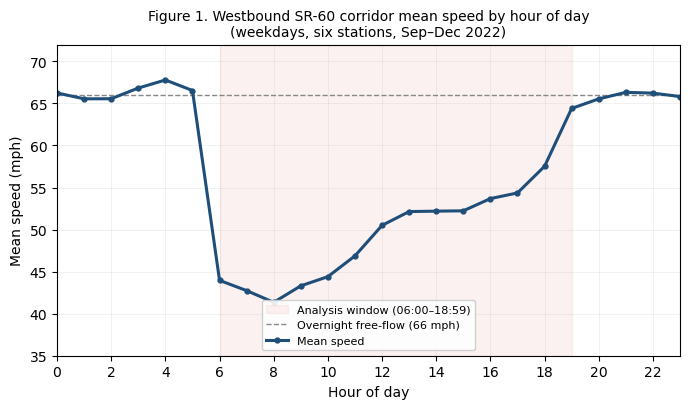

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load data and rebuild helper columns (self-contained) ---
data = pd.read_parquet("data/processed/sr60wb_5min_sep_dec_2022.parquet")
data["timestamp"] = pd.to_datetime(data["timestamp"])
data["hour"] = data["timestamp"].dt.hour
data["dow"]  = data["timestamp"].dt.dayofweek
data["date"] = data["timestamp"].dt.date

holidays = [pd.Timestamp("2022-09-05").date(), pd.Timestamp("2022-11-11").date(),
            pd.Timestamp("2022-11-24").date(), pd.Timestamp("2022-11-25").date()]
wk = data[(data["dow"] < 5) & (~data["date"].isin(holidays))]

# --- Hourly mean speed across the corridor ---
hourly = wk.groupby("hour")["speed"].mean().reindex(range(24))

# --- Free-flow reference line (overnight 00:00-03:59 mean) ---
freeflow = wk[wk["hour"] < 4]["speed"].mean()

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 4.2))

# Shade the analysis window (06:00-18:59)
ax.axvspan(6, 19, color="#d9534f", alpha=0.08, label="Analysis window (06:00–18:59)")

# Free-flow reference line
ax.axhline(freeflow, color="#888888", linestyle="--", linewidth=1,
           label=f"Overnight free-flow ({freeflow:.0f} mph)")

# Speed profile
ax.plot(hourly.index, hourly.values, color="#1f4e79", linewidth=2.2,
        marker="o", markersize=3.5, label="Mean speed")

ax.set_xlabel("Hour of day", fontsize=10)
ax.set_ylabel("Mean speed (mph)", fontsize=10)
ax.set_title("Figure 1. Westbound SR-60 corridor mean speed by hour of day\n"
             "(weekdays, six stations, Sep–Dec 2022)", fontsize=10)
ax.set_xticks(range(0, 24, 2))
ax.set_xlim(0, 23)
ax.set_ylim(35, 72)
ax.grid(True, alpha=0.25, linewidth=0.5)
ax.legend(fontsize=8, loc="lower center", framealpha=0.9)
fig.tight_layout()

# Save at print quality
fig.savefig("data/processed/figure1_speed_profile.png", dpi=300, bbox_inches="tight")
print("Saved: data/processed/figure1_speed_profile.png")
plt.show()

In [70]:
import os

for root, dirs, files in os.walk("."):
    # skip the big raw-data folder and hidden folders
    dirs[:] = [d for d in dirs if d not in ("raw",) and not d.startswith(".")]
    level = root.count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files):
        if not f.startswith("."):
            print(f"{indent}  {f}")

./
  00_setup.ipynb
  data/
    processed/
      crash_window_sensitivity.json
      decomposition_weekday_window.parquet
      eb_spike_result.json
      figure1_speed_profile.png
      headline_results.json
      monetization.json
      monetization_final.json
      sensitivity_decomposition.json
      sr60wb_5min_sep_dec_2022.parquet
      validation_matched.parquet
      validation_results.json
